# Auditoría del dataset fiel al paper (18 regímenes)

Este notebook audita la reconstrucción independiente del dataset de *Koopman Invariants as Drivers of Emergent Time-Series Clustering in Joint-Embedding Predictive Architectures*. La pregunta no es solamente si el código genera 18 etiquetas, sino si las señales resultantes conservan las propiedades publicadas y siguen siendo distinguibles después del preprocesamiento que recibirá el modelo.

**Alcance:** auditoría del dataset, sin entrenamiento. Los parámetros publicados y los supuestos locales están separados en `docs/PAPER_REPLICATION_SPEC.md`. Cada bloque incluye resultado, interpretación y una decisión.

In [1]:
# ruff: noqa: E402, E501
import math
import platform
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists(), "No se encontró la raíz del repositorio."
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import scipy
import torch
from IPython.display import Markdown, display
from statsmodels.tsa.arima_process import ArmaProcess

from koopman_jepa.paper_data import (
    PAPER_ARMA_COEFFICIENTS,
    PAPER_PERIODIC_CYCLES,
    PAPER_REGIME_NAMES,
    PaperDataConfig,
    PaperRegimeDataset,
    generate_paper_master,
    load_paper_data_config,
)

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")
print(f"PyTorch: {torch.__version__}")

Python: 3.13.12
NumPy: 2.5.3
SciPy: 1.18.1
PyTorch: 2.14.0


## Protocolo y criterios

La configuración de auditoría usa la geometría publicada: masters de 1024 puntos, contexto de 768, target desplazado 256 y estandarización por master antes de extraer ventanas. Para los gráficos agregados usamos 64 realizaciones reproducibles por régimen; las pruebas de eventos raros usan muestras mayores.

Los gates son:

1. **Mecánica:** 18 regímenes, geometría exacta, valores finitos, determinismo y estandarización correcta.
2. **Dinámica:** frecuencias, ACF, transiciones y eventos concuerdan con cada proceso.
3. **Identificabilidad:** las etiquetas deben conservar diferencias observables después de estandarizar.
4. **Sensibilidad:** los detalles ausentes del paper no deben cambiar silenciosamente la naturaleza de un régimen.

Un fallo de identificabilidad bloquea el entrenamiento aunque todos los tests de software pasen.

In [2]:
config = load_paper_data_config(ROOT / "configs" / "paper_dataset_audit.yaml")
AUDIT_SEQUENCES = 64
LENGTH = config.master_length

def sequence_rng(regime_id, sequence_id):
    seed = np.random.SeedSequence([config.base_seed, regime_id, sequence_id])
    return np.random.default_rng(seed)

raw_samples = np.empty((len(PAPER_REGIME_NAMES), AUDIT_SEQUENCES, LENGTH), dtype=np.float32)
for regime_id in range(len(PAPER_REGIME_NAMES)):
    for sequence_id in range(AUDIT_SEQUENCES):
        raw_samples[regime_id, sequence_id] = generate_paper_master(
            regime_id, LENGTH, sequence_rng(regime_id, sequence_id)
        )

working_samples = raw_samples.astype(np.float64)
means = working_samples.mean(axis=-1, keepdims=True)
stds = working_samples.std(axis=-1, keepdims=True)
standardized_samples = (working_samples - means) / np.maximum(stds, 1e-6)

print(f"Muestra de auditoría: {raw_samples.shape}")
print(f"Memoria raw: {raw_samples.nbytes / 2**20:.1f} MiB")

Muestra de auditoría: (18, 64, 1024)
Memoria raw: 4.5 MiB


In [3]:
full_config = PaperDataConfig()
repeated = generate_paper_master(17, LENGTH, sequence_rng(17, 3))
original = generate_paper_master(17, LENGTH, sequence_rng(17, 3))
full_size = len(PAPER_REGIME_NAMES) * (
    full_config.train_per_regime
    + full_config.val_per_regime
    + full_config.test_per_regime
)

mechanical_gates = {
    "18 regímenes": len(PAPER_REGIME_NAMES) == 18,
    "180000 pares en configuración completa": full_size == 180_000,
    "geometría 1024/768/256": (
        config.master_length, config.context_length, config.shift
    ) == (1024, 768, 256),
    "todos los valores son finitos": bool(np.isfinite(raw_samples).all()),
    "RNG determinista por secuencia": bool(np.array_equal(original, repeated)),
    "media estandarizada < 1e-5": float(np.abs(standardized_samples.mean(-1)).max()) < 1e-5,
    "error de std estandarizada < 1e-5": (
        float(np.abs(standardized_samples.std(-1) - 1.0).max()) < 1e-5
    ),
}
for name, passed in mechanical_gates.items():
    print(f"{'PASS' if passed else 'FAIL':4s} | {name}")
mechanical_pass = all(mechanical_gates.values())
print(f"\nGate mecánico global: {'PASS' if mechanical_pass else 'FAIL'}")

PASS | 18 regímenes
PASS | 180000 pares en configuración completa
PASS | geometría 1024/768/256
PASS | todos los valores son finitos
PASS | RNG determinista por secuencia
PASS | media estandarizada < 1e-5
PASS | error de std estandarizada < 1e-5

Gate mecánico global: PASS


### Interpretación del gate mecánico

La ejecución confirma que la implementación cubre los 18 regímenes, respeta el tamaño completo de 180.000 pares y produce exactamente la misma señal al repetir una clave de secuencia. Las medias y desviaciones posteriores al preprocesamiento están dentro de tolerancia numérica.

**Veredicto:** pasa la mecánica del dataset. Esto demuestra consistencia del pipeline, pero todavía no demuestra que las 18 etiquetas sean estadísticamente distintas.

## 1. Galería de señales raw

Cada panel muestra la primera realización de un régimen antes de estandarizar. Los ejes verticales son independientes para no ocultar señales de baja amplitud.

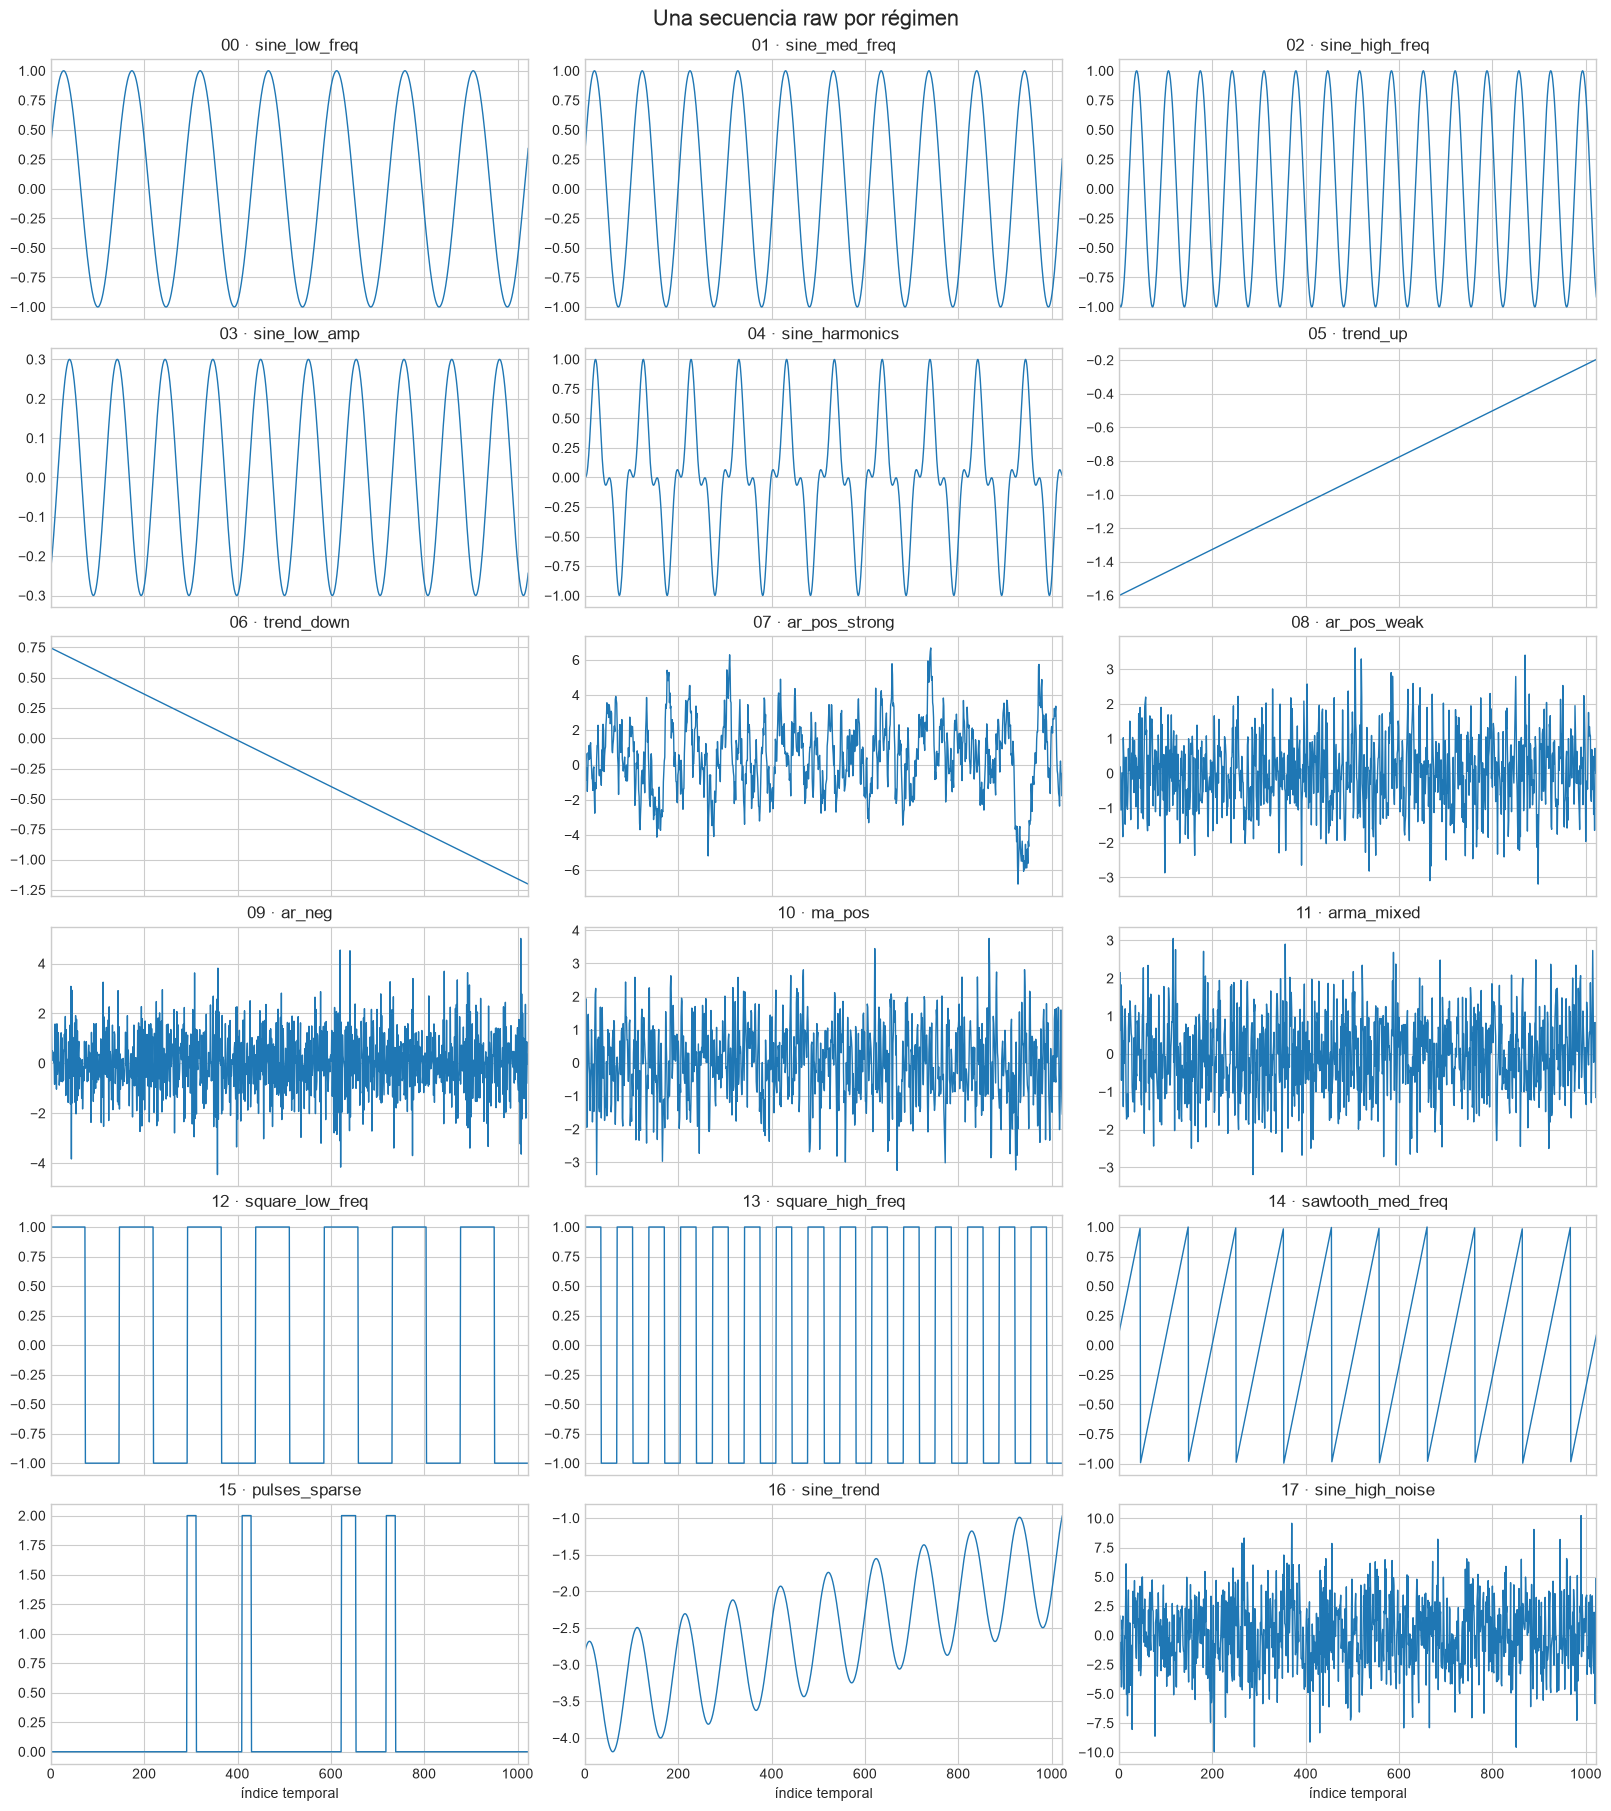

In [4]:
fig, axes = plt.subplots(6, 3, figsize=(16, 18), sharex=True, constrained_layout=True)
for regime_id, axis in enumerate(axes.flat):
    axis.plot(raw_samples[regime_id, 0], linewidth=1.0)
    axis.set_title(f"{regime_id:02d} · {PAPER_REGIME_NAMES[regime_id]}")
    axis.set_xlim(0, LENGTH - 1)
for axis in axes[-1]:
    axis.set_xlabel("índice temporal")
fig.suptitle("Una secuencia raw por régimen", fontsize=16)
plt.show()

### Lectura de la galería raw

Las familias publicadas aparecen cualitativamente: sinusoides con 7/10/15 ciclos, armónicos, rampas, procesos estocásticos, ondas no suaves, pulsos y combinaciones. Antes de estandarizar, `sine_low_amp` sí tiene menor amplitud que `sine_med_freq`. `sine_high_noise` está dominado visualmente por ruido, coherente con su SNR nominal de −12.55 dB.

Las tendencias muestran interceptos y pendientes diferentes por realización. Esas diferencias raw no garantizan diferencias para el modelo, porque el modelo recibe la versión estandarizada.

## 2. Qué sobrevive a la estandarización

Esta es la representación efectiva que se corta en contexto y target. La comparación raw/estandarizada es central: el preprocesamiento puede eliminar precisamente el atributo que define una etiqueta.

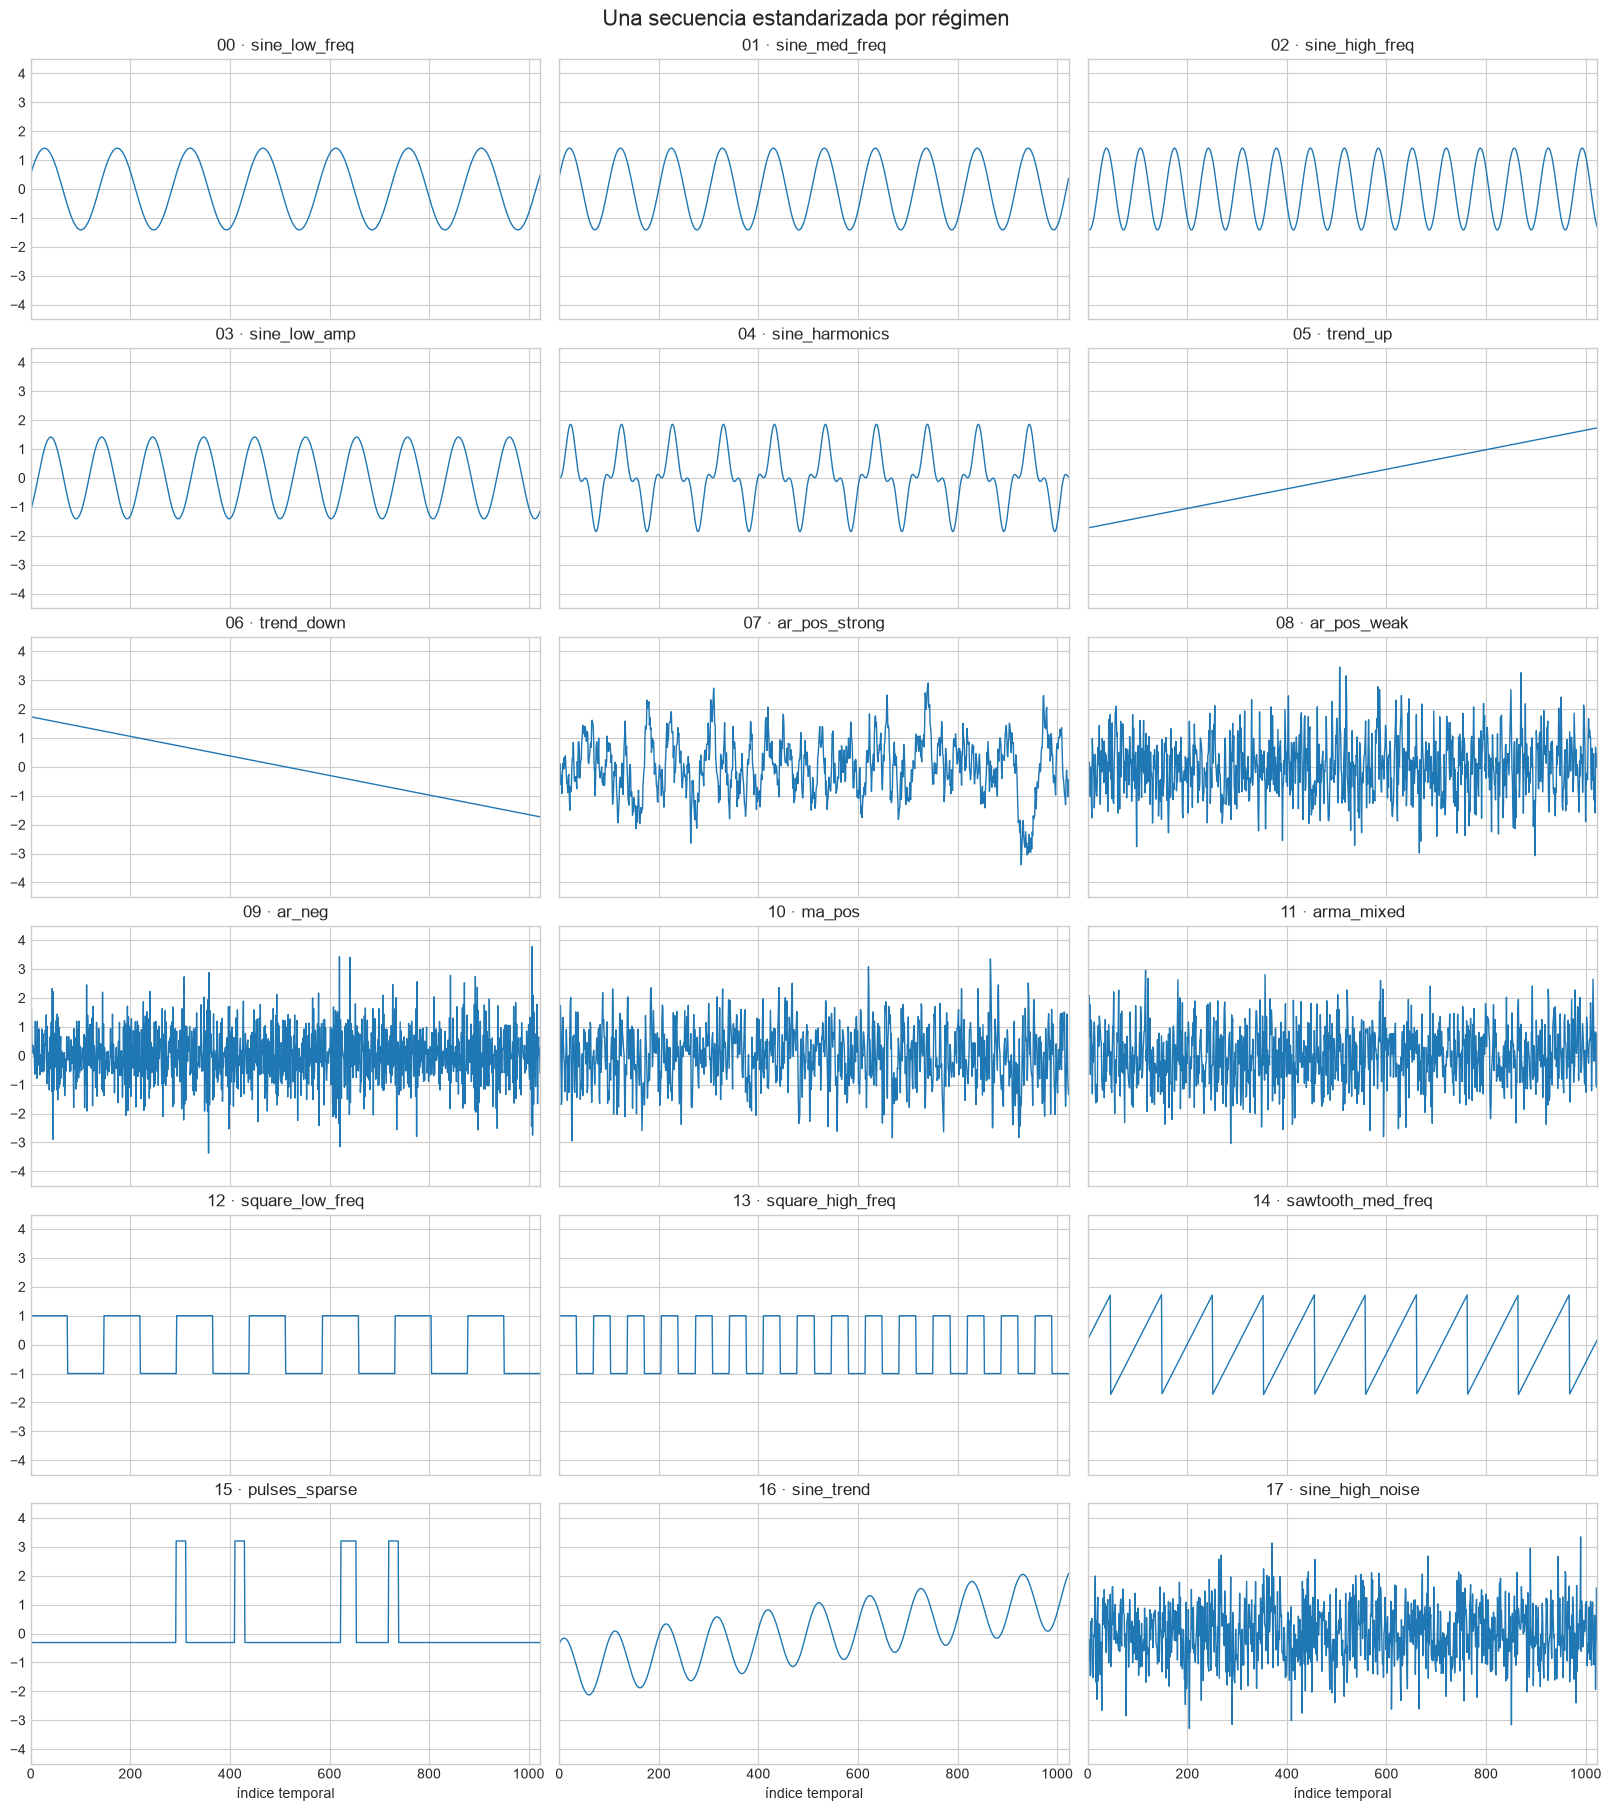

Máxima diferencia con igual fase tras estandarizar: 1.192e-07


In [5]:
fig, axes = plt.subplots(6, 3, figsize=(16, 18), sharex=True, sharey=True, constrained_layout=True)
for regime_id, axis in enumerate(axes.flat):
    axis.plot(standardized_samples[regime_id, 0], linewidth=1.0)
    axis.set_title(f"{regime_id:02d} · {PAPER_REGIME_NAMES[regime_id]}")
    axis.set_xlim(0, LENGTH - 1)
    axis.set_ylim(-4.5, 4.5)
for axis in axes[-1]:
    axis.set_xlabel("índice temporal")
fig.suptitle("Una secuencia estandarizada por régimen", fontsize=16)
plt.show()

paired_seed = 314159
medium = generate_paper_master(1, LENGTH, np.random.default_rng(paired_seed))
low_amplitude = generate_paper_master(3, LENGTH, np.random.default_rng(paired_seed))
medium_z = (medium - medium.mean()) / medium.std()
low_amplitude_z = (low_amplitude - low_amplitude.mean()) / low_amplitude.std()
paired_error = float(np.max(np.abs(medium_z - low_amplitude_z)))
print(f"Máxima diferencia con igual fase tras estandarizar: {paired_error:.3e}")

### Hallazgo crítico: una etiqueta pierde su definición

La diferencia entre `sine_med_freq` y `sine_low_amp` es sólo un factor de escala: (x_{low}=0.3x_{med}). Estandarizar cada master por separado elimina exactamente ese factor. Con la misma fase, ambas entradas estandarizadas coinciden hasta redondeo de coma flotante; con fases aleatorias independientes, ambas clases siguen teniendo la misma distribución.

Esto no es un problema estético: ninguna representación puede recuperar de la entrada una etiqueta cuya información fue eliminada. En consecuencia, el dataset contiene 18 nombres pero, bajo la especificación publicada, como máximo 17 distribuciones observables distintas.

**Veredicto de identificabilidad:** **FAIL crítico** para la afirmación de 18 regímenes distinguibles. No se debe entrenar sin decidir cómo reportar o investigar esta contradicción.

## 3. Geometría contexto–target

Auditamos que la estandarización ocurra sobre el master completo y que las ventanas compartan exactamente 512 muestras.

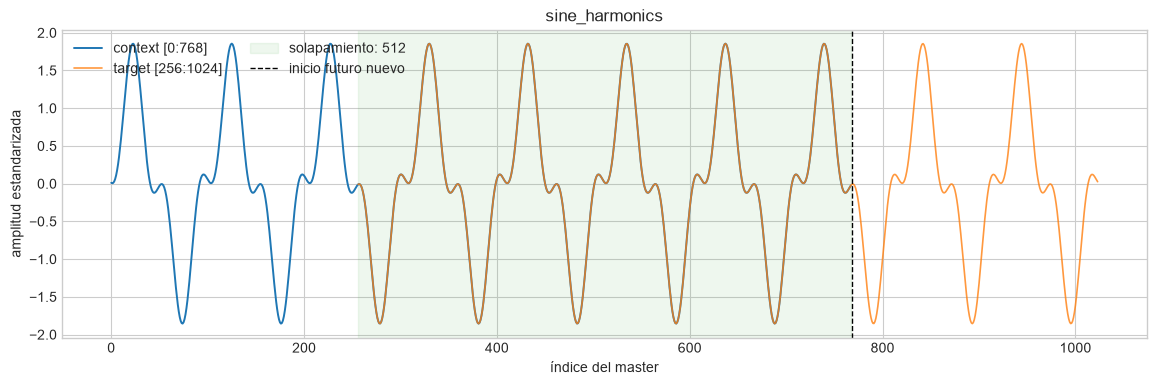

Forma context: (768,); forma target: (768,)
Error máximo en el solapamiento: 0.000e+00


In [6]:
dataset = PaperRegimeDataset(config, "train", generate_paper_master)
index = 4 * config.train_per_regime
context, target, label = dataset[index]
context = context.squeeze(0).numpy()
target = target.squeeze(0).numpy()
context_time = np.arange(config.context_length)
target_time = np.arange(config.shift, config.shift + config.context_length)
overlap_error = float(np.max(np.abs(context[config.shift:] - target[:-config.shift])))

fig, axis = plt.subplots(figsize=(14, 4))
axis.plot(context_time, context, label="context [0:768]", linewidth=1.4)
axis.plot(target_time, target, label="target [256:1024]", linewidth=1.2, alpha=0.8)
axis.axvspan(256, 767, color="tab:green", alpha=0.08, label="solapamiento: 512")
axis.axvline(768, color="black", linestyle="--", linewidth=1, label="inicio futuro nuevo")
axis.set(xlabel="índice del master", ylabel="amplitud estandarizada", title=PAPER_REGIME_NAMES[label.item()])
axis.legend(ncol=2)
plt.show()

print(f"Forma context: {context.shape}; forma target: {target.shape}")
print(f"Error máximo en el solapamiento: {overlap_error:.3e}")

### Interpretación de la geometría

Las dos curvas coinciden exactamente en los 512 puntos compartidos; el target aporta 256 puntos futuros nuevos. El gate geométrico pasa. La gran zona compartida hace que consistencia de representación e inferencia del futuro estén mezcladas en la loss, algo que habrá que recordar al interpretar resultados del JEPA.

## 4. Auditoría espectral de señales periódicas

Promediamos potencia sobre 64 secuencias ya estandarizadas. Así verificamos las frecuencias que realmente ve el encoder, no sólo las fórmulas raw.

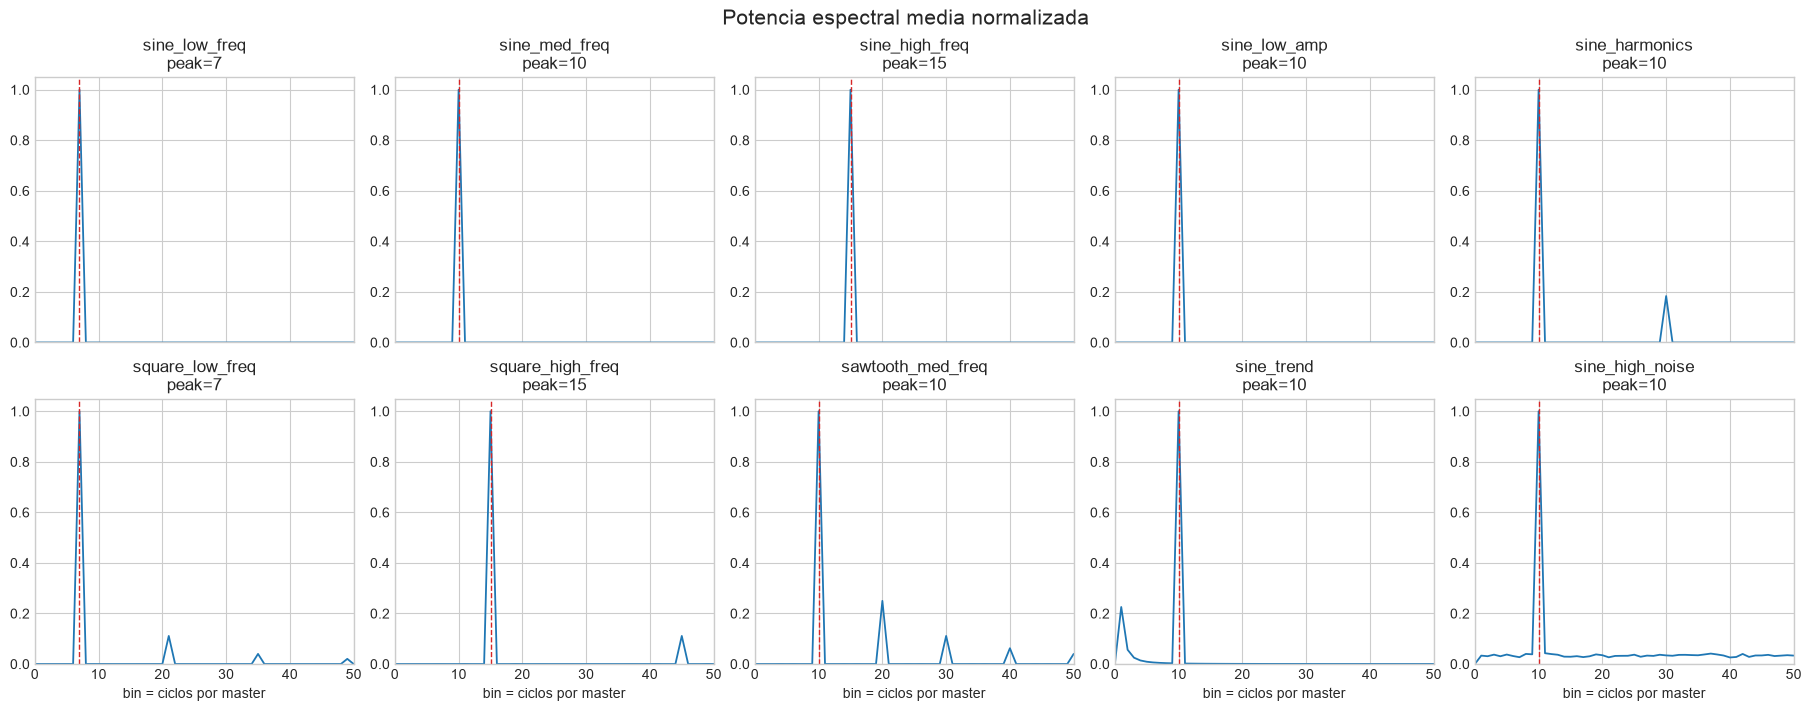

sine_low_freq        peak= 7
sine_med_freq        peak=10
sine_high_freq       peak=15
sine_low_amp         peak=10
sine_harmonics       peak=10
square_low_freq      peak= 7
square_high_freq     peak=15
sawtooth_med_freq    peak=10
sine_trend           peak=10
sine_high_noise      peak=10


In [7]:
periodic_ids = [0, 1, 2, 3, 4, 12, 13, 14, 16, 17]
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, constrained_layout=True)
spectral_summary = {}
for regime_id, axis in zip(periodic_ids, axes.flat, strict=True):
    spectrum = np.fft.rfft(standardized_samples[regime_id], axis=-1)
    mean_power = np.mean(np.abs(spectrum) ** 2, axis=0)
    dominant_bin = int(np.argmax(mean_power[1:]) + 1)
    spectral_summary[PAPER_REGIME_NAMES[regime_id]] = dominant_bin
    axis.plot(mean_power[:51] / mean_power[1:].max(), linewidth=1.3)
    axis.axvline(dominant_bin, color="tab:red", linestyle="--", linewidth=1)
    axis.set_title(f"{PAPER_REGIME_NAMES[regime_id]}\npeak={dominant_bin}")
    axis.set_xlim(0, 50)
    axis.set_ylim(0, 1.05)
for axis in axes[-1]:
    axis.set_xlabel("bin = ciclos por master")
fig.suptitle("Potencia espectral media normalizada", fontsize=15)
plt.show()

for name, dominant_bin in spectral_summary.items():
    print(f"{name:20s} peak={dominant_bin:2d}")

### Interpretación espectral

Los picos principales recuperan 7, 10 y 15 ciclos. Las ondas cuadradas añaden armónicos impares; el sawtooth reparte energía entre múltiples armónicos; `sine_harmonics` contiene los bins 10 y 30. El pico de 10 ciclos también emerge en promedio para `sine_high_noise`, aunque una secuencia individual esté dominada por ruido.

La coincidencia espectral entre `sine_med_freq` y `sine_low_amp` después de estandarizar no es aproximada sino estructural, confirmando el fallo de identificabilidad anterior.

## 5. ACF de los procesos AR/MA/ARMA

Comparamos la autocorrelación empírica media con la ACF teórica de `ArmaProcess`. Una coincidencia aquí valida signos y convenciones polinomiales.

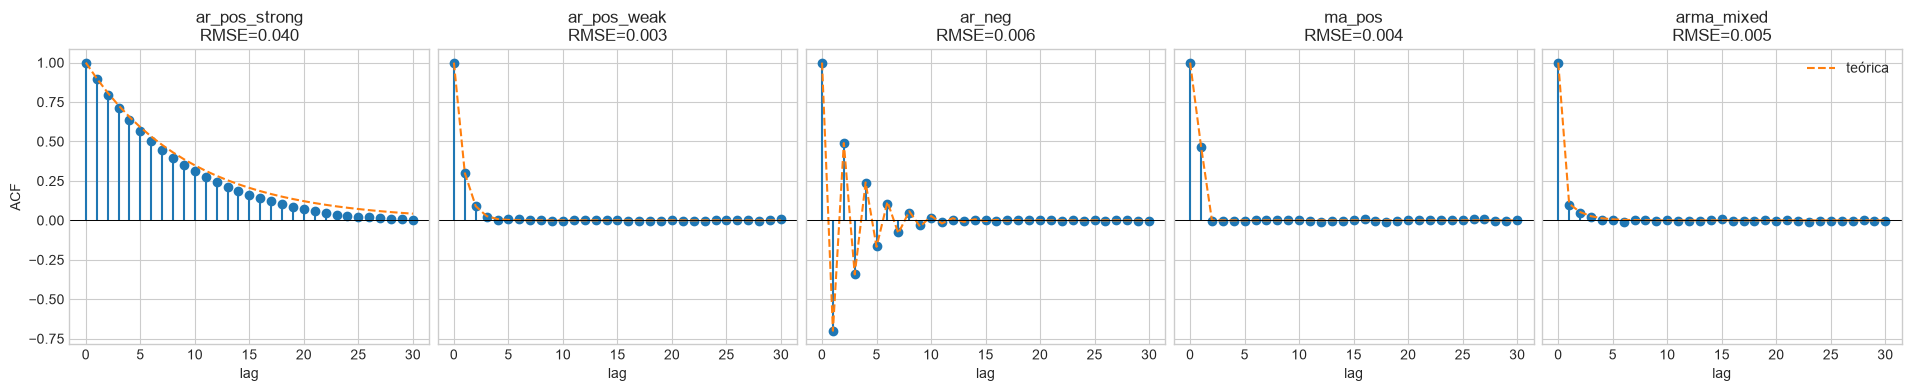

ar_pos_strong        RMSE=0.0400
ar_pos_weak          RMSE=0.0033
ar_neg               RMSE=0.0062
ma_pos               RMSE=0.0041
arma_mixed           RMSE=0.0048


In [8]:
def mean_acf(samples, max_lag):
    centered = samples - samples.mean(axis=1, keepdims=True)
    denominator = np.sum(centered**2, axis=1)
    values = [np.ones(samples.shape[0])]
    for lag in range(1, max_lag + 1):
        numerator = np.sum(centered[:, :-lag] * centered[:, lag:], axis=1)
        values.append(numerator / denominator)
    return np.mean(np.stack(values, axis=1), axis=0)

max_lag = 30
fig, axes = plt.subplots(1, 5, figsize=(19, 3.8), sharey=True, constrained_layout=True)
acf_rmse = {}
for regime_id, axis in zip(range(7, 12), axes, strict=True):
    ar_coefficients, ma_coefficients = PAPER_ARMA_COEFFICIENTS[regime_id]
    process = ArmaProcess(
        np.array((1.0, *(-value for value in ar_coefficients))),
        np.array((1.0, *ma_coefficients)),
    )
    empirical = mean_acf(standardized_samples[regime_id], max_lag)
    theoretical = process.acf(lags=max_lag + 1)
    rmse = float(np.sqrt(np.mean((empirical - theoretical) ** 2)))
    acf_rmse[PAPER_REGIME_NAMES[regime_id]] = rmse
    axis.stem(range(max_lag + 1), empirical, linefmt="C0-", markerfmt="C0o", basefmt=" ")
    axis.plot(theoretical, "C1--", label="teórica")
    axis.axhline(0, color="black", linewidth=0.7)
    axis.set_title(f"{PAPER_REGIME_NAMES[regime_id]}\nRMSE={rmse:.3f}")
    axis.set_xlabel("lag")
axes[0].set_ylabel("ACF")
axes[-1].legend()
plt.show()

for name, rmse in acf_rmse.items():
    print(f"{name:20s} RMSE={rmse:.4f}")

### Interpretación de la ACF

Las curvas empíricas siguen las firmas esperadas: decaimiento positivo lento para AR(0.9), decaimiento más rápido para AR(0.3), alternancia para AR(−0.7), corte tras el lag 1 para MA(1) y la combinación casi cancelada de corto alcance para ARMA(1,1).

**Veredicto dinámico:** pasa para coeficientes y signos. La comparación no resuelve por sí sola el estado inicial; eso se audita separadamente.

## 6. Tendencias: solapamiento de etiquetas

La lectura literal del apéndice usa pendiente base más una Normal(0,1). Estimamos la pendiente raw de 2.000 secuencias por clase y medimos cuántas contradicen el nombre de la etiqueta.

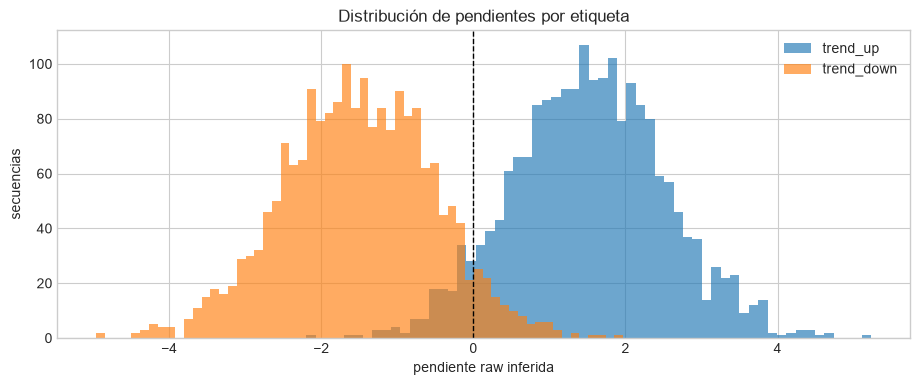

Trend_Up con pendiente negativa: 6.80%
Trend_Down con pendiente positiva: 6.00%
Probabilidad teórica por cola: 6.68%


In [9]:
TREND_SAMPLES = 2_000
trend_slopes = {}
for regime_id in (5, 6):
    values = []
    for sequence_id in range(TREND_SAMPLES):
        signal = generate_paper_master(regime_id, LENGTH, sequence_rng(regime_id, sequence_id))
        values.append(float(signal[-1] - signal[0]))
    trend_slopes[regime_id] = np.array(values)

up_reversal = float(np.mean(trend_slopes[5] < 0))
down_reversal = float(np.mean(trend_slopes[6] > 0))
expected_reversal = 0.5 * math.erfc(1.5 / math.sqrt(2.0))

fig, axis = plt.subplots(figsize=(11, 4))
axis.hist(trend_slopes[5], bins=60, alpha=0.65, label="trend_up")
axis.hist(trend_slopes[6], bins=60, alpha=0.65, label="trend_down")
axis.axvline(0, color="black", linestyle="--", linewidth=1)
axis.set(xlabel="pendiente raw inferida", ylabel="secuencias", title="Distribución de pendientes por etiqueta")
axis.legend()
plt.show()

print(f"Trend_Up con pendiente negativa: {up_reversal:.2%}")
print(f"Trend_Down con pendiente positiva: {down_reversal:.2%}")
print(f"Probabilidad teórica por cola: {expected_reversal:.2%}")

### Interpretación de las tendencias

Las dos distribuciones se solapan alrededor de cero y la tasa observada de inversión se aproxima al 6.68% teórico. Después de estandarizar, intercepto y magnitud desaparecen: una rampa sólo conserva el signo. Por ello, una fracción de `trend_up` se vuelve exactamente indistinguible de `trend_down`, y viceversa.

**Veredicto de identificabilidad:** advertencia fuerte. Es coherente con una lectura literal del texto, pero puede indicar que la implementación no publicada restringía el signo.

## 7. Pulsos y política de solapamiento

Nuestra baseline coloca cinco rectángulos, permite que sus intervalos se solapen y estandariza después. Medimos cuántos eventos visibles sobreviven.

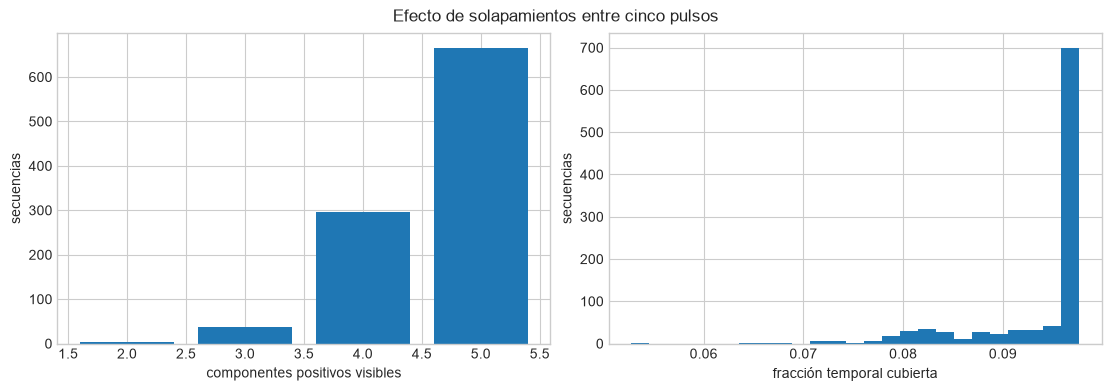

Secuencias con menos de 5 eventos visibles: 33.50%
Cobertura media: 9.43%


In [10]:
PULSE_SAMPLES = 1_000
component_counts = []
coverages = []
for sequence_id in range(PULSE_SAMPLES):
    signal = generate_paper_master(15, LENGTH, sequence_rng(15, sequence_id))
    mask = signal > 0
    starts = int(mask[0]) + int(np.count_nonzero((~mask[:-1]) & mask[1:]))
    component_counts.append(starts)
    coverages.append(mask.mean())
component_counts = np.array(component_counts)
coverages = np.array(coverages)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
values, counts = np.unique(component_counts, return_counts=True)
axes[0].bar(values, counts)
axes[0].set(xlabel="componentes positivos visibles", ylabel="secuencias")
axes[1].hist(coverages, bins=25)
axes[1].set(xlabel="fracción temporal cubierta", ylabel="secuencias")
fig.suptitle("Efecto de solapamientos entre cinco pulsos")
plt.show()

print(f"Secuencias con menos de 5 eventos visibles: {np.mean(component_counts < 5):.2%}")
print(f"Cobertura media: {coverages.mean():.2%}")

### Interpretación de pulsos

La mayoría de las secuencias conserva cinco componentes, pero los solapamientos o pulsos adyacentes pueden fusionar eventos. La estandarización elimina la amplitud absoluta 2.0; lo que queda para el encoder es ubicación, anchura, cobertura y cantidad de componentes.

**Veredicto:** la implementación es reproducible, pero esta política es una suposición local con efecto observable y debe permanecer en el análisis de sensibilidad.

## 8. Sensibilidad AR(0.9) al burn-in

El paper afirma que los procesos elegidos son estacionarios, pero no publica burn-in. `statsmodels` usa cero por defecto. Comparamos la varianza temporal entre la baseline y 256 pasos descartados, después de la misma estandarización por secuencia.

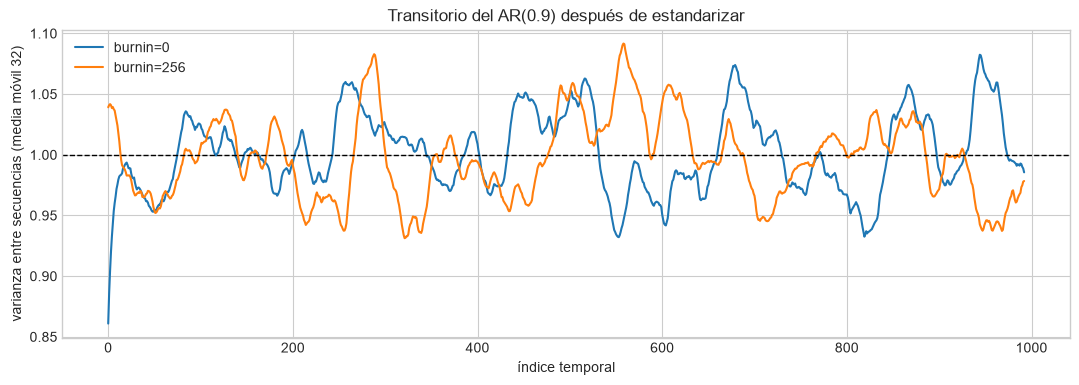

Ratio varianza inicial/final, burnin=0: 0.899
Ratio varianza inicial/final, burnin=256: 1.046


In [11]:
process = ArmaProcess(np.array([1.0, -0.9]), np.array([1.0]))
BURNIN_SAMPLES = 512

def standardized_ar_batch(burnin, seed):
    rng = np.random.default_rng(seed)
    samples = process.generate_sample(
        nsample=(BURNIN_SAMPLES, LENGTH),
        axis=1,
        distrvs=rng.standard_normal,
        burnin=burnin,
    )
    return (samples - samples.mean(axis=1, keepdims=True)) / samples.std(axis=1, keepdims=True)

zero_burnin = standardized_ar_batch(0, 123)
positive_burnin = standardized_ar_batch(256, 456)
variance_zero = zero_burnin.var(axis=0)
variance_positive = positive_burnin.var(axis=0)
window = np.ones(32) / 32

fig, axis = plt.subplots(figsize=(13, 4))
axis.plot(np.convolve(variance_zero, window, mode="valid"), label="burnin=0")
axis.plot(np.convolve(variance_positive, window, mode="valid"), label="burnin=256")
axis.axhline(1.0, color="black", linestyle="--", linewidth=1)
axis.set(xlabel="índice temporal", ylabel="varianza entre secuencias (media móvil 32)", title="Transitorio del AR(0.9) después de estandarizar")
axis.legend()
plt.show()

zero_ratio = float(variance_zero[:64].mean() / variance_zero[-64:].mean())
positive_ratio = float(variance_positive[:64].mean() / variance_positive[-64:].mean())
print(f"Ratio varianza inicial/final, burnin=0: {zero_ratio:.3f}")
print(f"Ratio varianza inicial/final, burnin=256: {positive_ratio:.3f}")

### Interpretación del burn-in

Con estado inicial cero, AR(0.9) necesita tiempo para alcanzar su varianza estacionaria; la estandarización global no elimina la forma temporal de ese transitorio. Con burn-in positivo, la varianza es mucho más homogénea desde el inicio.

**Veredicto de sensibilidad:** si el ratio inicial/final de `burnin=0` se aparta materialmente de 1, el default de la librería no es equivalente a una muestra estacionaria. Debemos ejecutar ambos casos o pedir aclaración antes de atribuir diferencias al JEPA.

## 9. Otras sensibilidades publicadas de forma incompleta

Evaluamos la escala temporal de `Sine_Trend`, la distribución de fase del sawtooth y el factor de ruido.

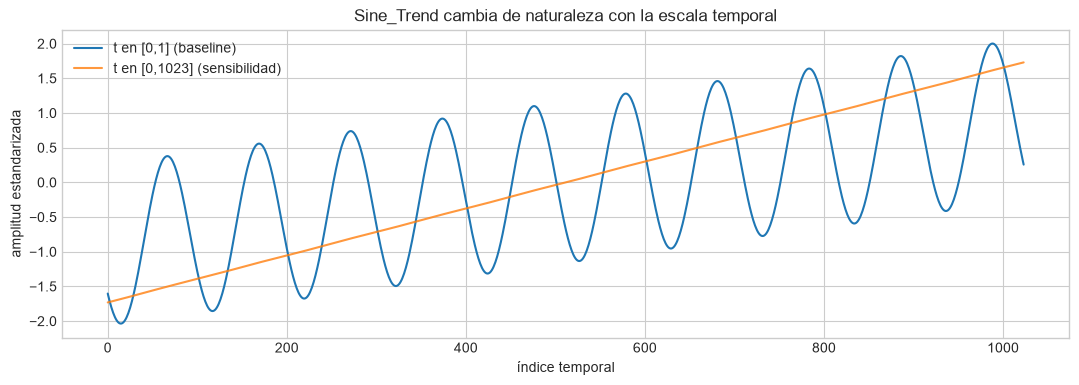

Fracción espectral bin 10, t normalizado: 0.731
Fracción espectral bin 10, índice directo: 0.006278
CV histograma fase uniforme: 0.018
CV fase Normal(0, pi²) envuelta: 0.020
sigma_noise=2.5 -> SNR=-10.97 dB
sigma_noise=3.0 -> SNR=-12.55 dB
sigma_noise=3.5 -> SNR=-13.89 dB


In [12]:
rng = np.random.default_rng(2026)
phase = rng.normal(0.0, np.pi)
slope = 1.0 + rng.normal(0.0, 1.0)
intercept = rng.normal(0.0, np.pi)
sample_time = np.arange(LENGTH)
normalized_time = np.linspace(0.0, 1.0, LENGTH)
sine = 0.8 * np.sin(2.0 * np.pi * PAPER_PERIODIC_CYCLES["medium"] * sample_time / LENGTH + phase)
local = sine + slope * normalized_time + intercept
index_scaled = sine + slope * sample_time + intercept
local_z = (local - local.mean()) / local.std()
index_z = (index_scaled - index_scaled.mean()) / index_scaled.std()

def spectral_fraction(signal, frequency_bin):
    power = np.abs(np.fft.rfft(signal)) ** 2
    return float(power[frequency_bin] / power[1:].sum())

fig, axis = plt.subplots(figsize=(13, 4))
axis.plot(local_z, label="t en [0,1] (baseline)")
axis.plot(index_z, label="t en [0,1023] (sensibilidad)", alpha=0.8)
axis.set(xlabel="índice temporal", ylabel="amplitud estandarizada", title="Sine_Trend cambia de naturaleza con la escala temporal")
axis.legend()
plt.show()

print(f"Fracción espectral bin 10, t normalizado: {spectral_fraction(local_z, 10):.3f}")
print(f"Fracción espectral bin 10, índice directo: {spectral_fraction(index_z, 10):.6f}")

phase_rng = np.random.default_rng(2027)
phase_count = 100_000
uniform_phase = phase_rng.uniform(0.0, 2.0 * np.pi, phase_count)
normal_phase = np.mod(phase_rng.normal(0.0, np.pi, phase_count), 2.0 * np.pi)
uniform_hist = np.histogram(uniform_phase, bins=24, range=(0, 2.0 * np.pi))[0]
normal_hist = np.histogram(normal_phase, bins=24, range=(0, 2.0 * np.pi))[0]
print(f"CV histograma fase uniforme: {uniform_hist.std() / uniform_hist.mean():.3f}")
print(f"CV fase Normal(0, pi²) envuelta: {normal_hist.std() / normal_hist.mean():.3f}")

for noise_std in (2.5, 3.0, 3.5):
    snr_db = 20.0 * np.log10((1.0 / np.sqrt(2.0)) / noise_std)
    print(f"sigma_noise={noise_std:.1f} -> SNR={snr_db:.2f} dB")

### Interpretación de sensibilidades

La escala temporal no es un detalle menor: con índices directos, la tendencia domina por órdenes de magnitud y el seno prácticamente desaparece después de estandarizar; con `t` en `[0,1]`, ambos componentes siguen visibles. Esto justifica nuestra baseline pero también muestra que no puede llamarse reproducción exacta sin aclaración.

La fase Normal envuelta no es matemáticamente uniforme, pero en 100.000 muestras y 24 bins su variación es prácticamente igual a la baseline uniforme (CV 0.020 frente a 0.018). Esta sensibilidad queda en baja prioridad. En cambio, el rango de ruido 2.5–3.5 cambia el SNR casi 3 dB y sí puede afectar separabilidad; debe acompañar cualquier resultado que dependa de ese régimen.

In [13]:
display(Markdown(f"""## Veredicto de la auditoría

- **Mecánica:** {'PASS' if mechanical_pass else 'FAIL'}. Geometría, determinismo, finitud y estandarización son correctos.
- **Dinámica:** **PASS provisional**. Frecuencias y ACF concuerdan con los procesos implementados.
- **Identificabilidad de 18 regímenes:** **FAIL crítico**. `Sine_MedFreq` y `Sine_LowAmp` son la misma distribución después de estandarizar; error pareado máximo = `{paired_error:.3e}`.
- **Etiquetas de tendencia:** **WARN**. Inversiones observadas: up `{up_reversal:.2%}`, down `{down_reversal:.2%}`.
- **Estado inicial ARMA:** **WARN**. Ratio de varianza inicial/final para AR(0.9): `{zero_ratio:.3f}` sin burn-in frente a `{positive_ratio:.3f}` con burn-in.
- **Supuestos locales:** **WARN** para escala de tendencia, fase sawtooth, pulsos y ruido alto.

### Decisión

**No entrenar todavía.** El generador funciona, pero el dataset publicado contiene al menos una equivalencia exacta creada por su propio preprocesamiento. Antes de entrenar debemos decidir si (a) mantenemos la especificación literal y reportamos 17 distribuciones observables bajo 18 etiquetas, (b) añadimos una variante sin estandarización para estudiar la amplitud, o (c) buscamos aclaración de los autores.
"""))

## Veredicto de la auditoría

- **Mecánica:** PASS. Geometría, determinismo, finitud y estandarización son correctos.
- **Dinámica:** **PASS provisional**. Frecuencias y ACF concuerdan con los procesos implementados.
- **Identificabilidad de 18 regímenes:** **FAIL crítico**. `Sine_MedFreq` y `Sine_LowAmp` son la misma distribución después de estandarizar; error pareado máximo = `1.192e-07`.
- **Etiquetas de tendencia:** **WARN**. Inversiones observadas: up `6.80%`, down `6.00%`.
- **Estado inicial ARMA:** **WARN**. Ratio de varianza inicial/final para AR(0.9): `0.899` sin burn-in frente a `1.046` con burn-in.
- **Supuestos locales:** **WARN** para escala de tendencia, fase sawtooth, pulsos y ruido alto.

### Decisión

**No entrenar todavía.** El generador funciona, pero el dataset publicado contiene al menos una equivalencia exacta creada por su propio preprocesamiento. Antes de entrenar debemos decidir si (a) mantenemos la especificación literal y reportamos 17 distribuciones observables bajo 18 etiquetas, (b) añadimos una variante sin estandarización para estudiar la amplitud, o (c) buscamos aclaración de los autores.
